In [ ]:
import os, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pennylane as qml

In [ ]:
#Conditional EQGAN on MNIST
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------ Hyperparameters ------------------
TOTAL_SAMPLES      = 5000   # balanced subset across 10 classes
BATCH_SIZE         = 128
EPOCHS             = 3
LR_G, LR_D         = 2e-3, 2e-3
USE_WGAN           = True   # set False for BCE-GAN (often a tad faster)
CRITIC_ITERS       = 2      # smaller critic steps for speed
CLIP_VALUE         = 0.01
N_GEN_LAYERS       = 1      # shallow
N_DISC_LAYERS      = 1      # shallow
TARGET_VAR         = 0.85   # PCA coverage (smaller → fewer qubits)
MIN_K, MAX_K       = 2, 4   # keep qubit count small
MAX_STEPS_PER_EPOCH= 80     # cap batches per epoch for speed (None to disable)

SAVE_DIR = "./c_eqgan_fast_ckpts"
os.makedirs(SAVE_DIR, exist_ok=True)

def load_uniform_mnist_subset(n_total=TOTAL_SAMPLES, download=True):
    ds = datasets.MNIST(
        root="./dataset", train=True,
        transform=transforms.ToTensor(), download=download
    )
    per_class = n_total // 10
    counts = {d:0 for d in range(10)}
    imgs, labels = [], []
    for x,y in ds:
        if counts[y] < per_class:
            imgs.append(x.numpy().squeeze())
            labels.append(int(y))
            counts[y] += 1
        if sum(counts.values()) >= per_class*10:
            break
    return np.asarray(imgs, dtype=np.float32), np.asarray(labels, dtype=np.int64)

X, y = load_uniform_mnist_subset()
N = X.shape[0]
X_flat = X.reshape(N, -1)

pca_full = PCA().fit(X_flat)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k_auto = int(np.searchsorted(cum, TARGET_VAR) + 1)
k = max(MIN_K, min(k_auto, MAX_K))
print(f"[PCA] Using k={k} PCs (target var ≥ {TARGET_VAR:.2f}).")

pca = PCA(n_components=k).fit(X_flat)
Z = pca.transform(X_flat)

# scale to [0,1] for stable angle embedding
mins, maxs = Z.min(axis=0), Z.max(axis=0)
ranges = np.maximum(maxs - mins, 1e-8)
Z01 = (Z - mins) / ranges

def inverse_pca(Z01_batch):
    Z_real = Z01_batch * ranges + mins
    X_rec = pca.inverse_transform(Z_real)
    return X_rec.reshape(-1, 28, 28)

data = torch.tensor(Z01, dtype=torch.float32)
labels = torch.tensor(y, dtype=torch.long)
loader = DataLoader(
    TensorDataset(data, labels),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    num_workers=2, pin_memory=True, persistent_workers=True
)

def lightning_or_default(n_wires):
    try:
        # lightning.qubit is much faster; shots=None → analytic
        return qml.device("lightning.qubit", wires=n_wires, shots=None)
    except Exception:
        return qml.device("default.qubit", wires=n_wires, shots=None)

def make_gen_qnode(n_qubits, n_layers):
    dev = lightning_or_default(n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="adjoint")
    def qnode(inputs, weights):
        qml.AngleEmbedding(inputs * math.pi, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        # Return k features in [-1,1]
        return [qml.expval(qml.PauliZ(i)) for i in range(k)]
    return qnode, {"weights": (n_layers, n_qubits, 3)}

def make_disc_qnode(n_qubits, n_layers):
    dev = lightning_or_default(n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="adjoint")
    def qnode(inputs, weights):
        qml.AngleEmbedding(inputs * math.pi, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        # Critic/logit on the last wire ([-1,1])
        return qml.expval(qml.PauliZ(n_qubits - 1))
    return qnode, {"weights": (n_layers, n_qubits, 3)}

N_QUBITS_G = k + 10         # features + label one-hot
N_QUBITS_D = k + 10 + 1     # features + label one-hot + ancilla

class QGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        qnode, wsh = make_gen_qnode(N_QUBITS_G, N_GEN_LAYERS)
        self.q_layer = qml.qnn.TorchLayer(qnode, wsh)
    def forward(self, noise, onehot):
        x = torch.cat([noise, onehot], dim=1)        # [B, k+10]
        out = self.q_layer(x)                        # [-1,1]
        return 0.5*(out + 1.0)                       # → [0,1]

class QDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        qnode, wsh = make_disc_qnode(N_QUBITS_D, N_DISC_LAYERS)
        self.q_layer = qml.qnn.TorchLayer(qnode, wsh)
    def forward(self, features, onehot):
        anc = torch.zeros((features.size(0), 1), device=features.device)
        x = torch.cat([features, onehot, anc], dim=1)  # [B, k+10+1]
        return self.q_layer(x)                         # critic/logit in [-1,1]

G, D = QGenerator().to(device), QDiscriminator().to(device)
optG = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.9))
optD = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.9))
bce  = nn.BCELoss()

def sample_noise(bsz, k):        # U(0,1) works fine with AngleEmbedding
    return torch.rand((bsz, k), device=device)

def one_hot(labels, n=10):
    return F.one_hot(labels, num_classes=n).float()

def clip_disc_weights():
    for p in D.parameters():
        p.data.clamp_(-CLIP_VALUE, CLIP_VALUE)

step = 0
for epoch in range(1, EPOCHS+1):
    for b, (real_feats, yb) in enumerate(loader):
        if MAX_STEPS_PER_EPOCH is not None and b >= MAX_STEPS_PER_EPOCH:
            break
        real_feats = real_feats.to(device)
        yb = yb.to(device)
        y_onehot = one_hot(yb)

        # ---- Train D (critic) ----
        d_steps = CRITIC_ITERS if USE_WGAN else 1
        for _ in range(d_steps):
            z = sample_noise(real_feats.size(0), k)
            fake_feats = G(z, y_onehot).detach()

            optD.zero_grad(set_to_none=True)
            d_real = D(real_feats, y_onehot)
            d_fake = D(fake_feats, y_onehot)

            if USE_WGAN:
                d_loss = -(torch.mean(d_real) - torch.mean(d_fake))
                d_loss.backward()
                optD.step()
                clip_disc_weights()
            else:
                ones  = torch.ones_like(d_real)
                zeros = torch.zeros_like(d_fake)
                d_loss = bce(torch.sigmoid(d_real), ones) + bce(torch.sigmoid(d_fake), zeros)
                d_loss.backward()
                optD.step()

        z = sample_noise(real_feats.size(0), k)
        optG.zero_grad(set_to_none=True)
        gen_feats = G(z, y_onehot)
        d_gen = D(gen_feats, y_onehot)
        g_loss = -torch.mean(d_gen) if USE_WGAN else bce(torch.sigmoid(d_gen), torch.ones_like(d_gen))
        g_loss.backward()
        optG.step()

        if step % 30 == 0:
            print(f"[E{epoch}/{EPOCHS} | step {step}] D={d_loss.item():.4f}  G={g_loss.item():.4f}")
        step += 1

    with torch.no_grad():
        G.eval()
        m = 16
        z = sample_noise(m, k)
        labels_grid = torch.arange(m, device=device) % 10
        y_oh = one_hot(labels_grid)
        gen = G(z, y_oh).cpu().numpy()
        imgs = inverse_pca(gen)

        plt.figure(figsize=(5,5))
        for i in range(m):
            ax = plt.subplot(4,4,i+1)
            ax.imshow(np.clip(imgs[i], 0, 1), cmap="gray")
            ax.set_title(int(labels_grid[i]), fontsize=8)
            ax.axis("off")
        plt.suptitle(f"Epoch {epoch} (k={k}, layers G/D={N_GEN_LAYERS}/{N_DISC_LAYERS})")
        plt.tight_layout()
        out_path = os.path.join(SAVE_DIR, f"epoch_{epoch:02d}_samples.png")
        plt.savefig(out_path, dpi=150)
        plt.close()
        G.train()

print("Done.")


[PCA] Using k=4 PCs (target var ≥ 0.85).


c:\Users\maya\gsoc\.conda\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[E1/3 | step 0] D=0.0020  G=-0.0000
[E1/3 | step 30] D=0.0022  G=0.0000
[E2/3 | step 60] D=-0.0002  G=-0.0000
[E3/3 | step 90] D=-0.0034  G=-0.0000
Done.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_generated_samples(G, k, ranges, mins, pca, device, num_samples=16):
    G.eval()
    with torch.no_grad():
        # 1) Sample random latent noise and fixed labels (0..9 repeating)
        z = torch.rand((num_samples, k), device=device)
        labels_grid = torch.arange(num_samples, device=device) % 10
        onehot = torch.nn.functional.one_hot(labels_grid, num_classes=10).float()

        # 2) Generate fake PCA features
        gen_feats = G(z, onehot).cpu().numpy()  # [num_samples, k] in [0,1]

        # 3) Inverse transform back to image space
        Z_real = gen_feats * ranges + mins
        X_rec = pca.inverse_transform(Z_real).reshape(-1, 28, 28)

        # 4) Plot grid
        plt.figure(figsize=(5, 5))
        for i in range(num_samples):
            ax = plt.subplot(4, 4, i + 1)
            ax.imshow(np.clip(X_rec[i], 0, 1), cmap="gray")
            ax.set_title(int(labels_grid[i]), fontsize=8)
            ax.axis("off")
        plt.suptitle("Generated Samples")
        plt.tight_layout()
        plt.show()


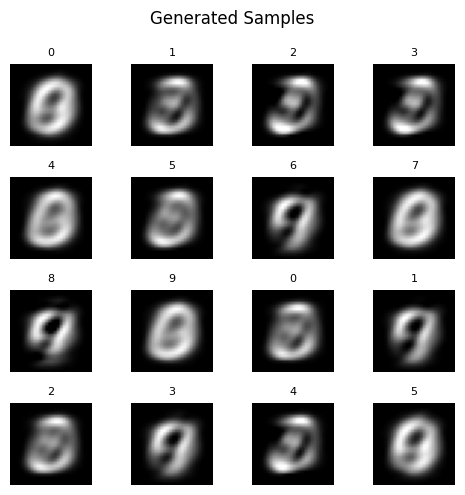

In [11]:
show_generated_samples(G, k, ranges, mins, pca, device)


In [ ]:

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TOTAL_SAMPLES      = 5000   # balanced subset
BATCH_SIZE         = 128
EPOCHS             = 5
LR_G, LR_D         = 1.5e-3, 2e-3     # TTUR: critic a bit faster
BETA1, BETA2       = 0.5, 0.9
TARGET_VAR         = 0.85
MIN_K, MAX_K       = 2, 4
N_GEN_LAYERS       = 1
N_DISC_LAYERS      = 1
CRITIC_ITERS       = 4
LAMBDA_GP          = 10.0             # WGAN-GP coefficient
MMD_LAMBDA         = 1.0              # diversity regularizer on G
INST_NOISE_START   = 0.10             # σ at epoch 1
INST_NOISE_END     = 0.00             # σ at last epoch
SAVE_DIR           = "./c_eqgan_gp_ckpts"
os.makedirs(SAVE_DIR, exist_ok=True)

def load_uniform_mnist_subset(n_total=TOTAL_SAMPLES, download=True):
    ds = datasets.MNIST(
        root="./dataset", train=True,
        transform=transforms.ToTensor(), download=download
    )
    per_class = n_total // 10
    counts = {d:0 for d in range(10)}
    imgs, labels = [], []
    for x,y in ds:
        if counts[y] < per_class:
            imgs.append(x.numpy().squeeze())
            labels.append(int(y))
            counts[y] += 1
        if sum(counts.values()) >= per_class*10:
            break
    return np.asarray(imgs, dtype=np.float32), np.asarray(labels, dtype=np.int64)

X, y = load_uniform_mnist_subset()
N = X.shape[0]
X_flat = X.reshape(N, -1)

pca_full = PCA().fit(X_flat)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k_auto = int(np.searchsorted(cum, TARGET_VAR) + 1)
k = max(MIN_K, min(k_auto, MAX_K))
print(f"[PCA] Using k={k} PCs (target var ≥ {TARGET_VAR:.2f}).")

pca = PCA(n_components=k).fit(X_flat)
Z = pca.transform(X_flat)

# scale to [0,1] for stable angle embedding
mins, maxs = Z.min(axis=0), Z.max(axis=0)
ranges = np.maximum(maxs - mins, 1e-8)
Z01 = (Z - mins) / ranges

def inverse_pca(Z01_batch):
    Z_real = Z01_batch * ranges + mins
    X_rec = pca.inverse_transform(Z_real)
    return X_rec.reshape(-1, 28, 28)

data = torch.tensor(Z01, dtype=torch.float32)
labels = torch.tensor(y, dtype=torch.long)
loader = DataLoader(
    TensorDataset(data, labels),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    num_workers=2, pin_memory=True, persistent_workers=True
)

def lightning_or_default(n_wires):
    try:
        return qml.device("lightning.qubit", wires=n_wires, shots=None)
    except Exception:
        return qml.device("default.qubit", wires=n_wires, shots=None)

def make_gen_qnode(n_qubits, n_layers):
    dev = lightning_or_default(n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="adjoint")
    def qnode(inputs, weights):
        qml.AngleEmbedding(inputs * math.pi, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        # Return k features in [-1,1]
        return [qml.expval(qml.PauliZ(i)) for i in range(k)]
    return qnode, {"weights": (n_layers, n_qubits, 3)}

def make_disc_qnode(n_qubits, n_layers):
    dev = lightning_or_default(n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="adjoint")
    def qnode(inputs, weights):
        qml.AngleEmbedding(inputs * math.pi, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        # Critic/logit on the last wire (≈[-1,1])
        return qml.expval(qml.PauliZ(n_qubits - 1))
    return qnode, {"weights": (n_layers, n_qubits, 3)}

N_QUBITS_G = k + 10         # noise/features + label one-hot
N_QUBITS_D = k + 10 + 1     # features + label one-hot + ancilla

class QGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        qnode, wsh = make_gen_qnode(N_QUBITS_G, N_GEN_LAYERS)
        self.q_layer = qml.qnn.TorchLayer(qnode, wsh)
    def forward(self, noise, onehot):
        x = torch.cat([noise, onehot], dim=1)          # [B, k+10]
        out = self.q_layer(x)                          # [-1,1]
        return 0.5*(out + 1.0)                         # → [0,1]

class QDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        qnode, wsh = make_disc_qnode(N_QUBITS_D, N_DISC_LAYERS)
        self.q_layer = qml.qnn.TorchLayer(qnode, wsh)
    def forward(self, features, onehot):
        anc = torch.zeros((features.size(0), 1), device=features.device)
        x = torch.cat([features, onehot, anc], dim=1)  # [B, k+10+1]
        return self.q_layer(x)                         # critic/logit

G, D = QGenerator().to(device), QDiscriminator().to(device)
optG = optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, BETA2))
optD = optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, BETA2))

def sample_noise(bsz, k):      # U(0,1) works with AngleEmbedding
    return torch.rand((bsz, k), device=device)

def one_hot(labels, n=10):
    return F.one_hot(labels, num_classes=n).float()

def instance_noise_sigma(epoch, total_epochs):
    # linear anneal from INST_NOISE_START → INST_NOISE_END
    t = (epoch - 1) / max(total_epochs - 1, 1)
    return INST_NOISE_START * (1 - t) + INST_NOISE_END * t

def add_instance_noise(x, sigma):
    if sigma <= 0:
        return x
    return x + sigma * torch.randn_like(x)

# WGAN-GP gradient penalty on interpolated inputs
def gradient_penalty(D, real, fake, onehot):
    eps = torch.rand((real.size(0), 1), device=device)
    eps = eps.expand_as(real)
    interp = eps * real + (1 - eps) * fake
    interp.requires_grad_(True)
    d_interp = D(interp, onehot)
    grad = torch.autograd.grad(
        outputs=d_interp.sum(), inputs=interp,
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grad_norm = grad.view(grad.size(0), -1).norm(2, dim=1)
    gp = ((grad_norm - 1.0) ** 2).mean()
    return gp

# RBF-MMD (encourages diversity)
def mmd_rbf(x, y, sigma=0.2):
    # x,y: [B,k] in [0,1]
    def pdist(a, b):
        aa = (a*a).sum(dim=1, keepdim=True)
        bb = (b*b).sum(dim=1, keepdim=True).T
        ab = a @ b.T
        d2 = aa + bb - 2*ab
        return torch.clamp(d2, min=0.0)
    kxx = torch.exp(-pdist(x, x) / (2*sigma*sigma))
    kyy = torch.exp(-pdist(y, y) / (2*sigma*sigma))
    kxy = torch.exp(-pdist(x, y) / (2*sigma*sigma))
    # unbiased estimate
    n = x.size(0)
    m = y.size(0)
    mmd = (kxx.sum()-kxx.diag().sum())/(n*(n-1)) \
        + (kyy.sum()-kyy.diag().sum())/(m*(m-1)) \
        - 2*kxy.mean()
    return mmd

step = 0
for epoch in range(1, EPOCHS+1):
    sig = instance_noise_sigma(epoch, EPOCHS)
    for real_feats, yb in loader:
        real_feats = real_feats.to(device)
        yb = yb.to(device)
        y_onehot = one_hot(yb)

        for _ in range(CRITIC_ITERS):
            z = sample_noise(real_feats.size(0), k)
            with torch.no_grad():
                fake_feats = G(z, y_onehot)
            # instance noise to both real and fake
            real_n = add_instance_noise(real_feats, sig)
            fake_n = add_instance_noise(fake_feats, sig)

            optD.zero_grad(set_to_none=True)
            d_real = D(real_n, y_onehot)
            d_fake = D(fake_n, y_onehot)
            gp = gradient_penalty(D, real_n, fake_n, y_onehot)

            d_loss = -(torch.mean(d_real) - torch.mean(d_fake)) + LAMBDA_GP * gp
            d_loss.backward()
            optD.step()
            step += 1

        z = sample_noise(real_feats.size(0), k)
        optG.zero_grad(set_to_none=True)
        gen_feats = G(z, y_onehot)
        d_gen = D(add_instance_noise(gen_feats, sig), y_onehot)
        g_adv = -torch.mean(d_gen)
        mmd = mmd_rbf(gen_feats.detach(), real_feats)  # detach real for stability
        g_loss = g_adv + MMD_LAMBDA * mmd
        g_loss.backward()
        optG.step()

    print(f"[Epoch {epoch}/{EPOCHS}] D={d_loss.item():.4f}  G={g_adv.item():.4f}  GP={gp.item():.3f}  MMD={mmd.item():.3f}  σ={sig:.3f}")

    with torch.no_grad():
        G.eval()
        m = 16
        z = sample_noise(m, k)
        labels_grid = torch.arange(m, device=device) % 10
        y_oh = one_hot(labels_grid)
        gen = G(z, y_oh).cpu().numpy()              # [m,k] in [0,1]
        imgs = inverse_pca(gen)

        plt.figure(figsize=(5,5))
        for i in range(m):
            ax = plt.subplot(4,4,i+1)
            ax.imshow(np.clip(imgs[i], 0, 1), cmap="gray")
            ax.set_title(int(labels_grid[i]), fontsize=8)
            ax.axis("off")
        plt.suptitle(f"Epoch {epoch} (k={k}, GP, MMD, σ={sig:.2f})")
        plt.tight_layout()
        out_path = os.path.join(SAVE_DIR, f"epoch_{epoch:02d}_samples.png")
        plt.savefig(out_path, dpi=150)
        plt.close()
        G.train()

print("Done.")


[PCA] Using k=4 PCs (target var ≥ 0.85).


c:\Users\maya\gsoc\.conda\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Epoch 1/5] D=9.7028  G=0.0011  GP=0.970  MMD=0.295  σ=0.100
[Epoch 2/5] D=3.3525  G=0.0595  GP=0.342  MMD=0.284  σ=0.075
[Epoch 3/5] D=2.6318  G=0.2841  GP=0.290  MMD=0.272  σ=0.050
[Epoch 4/5] D=14.8355  G=0.4411  GP=1.529  MMD=0.271  σ=0.025
[Epoch 5/5] D=18.1747  G=0.4686  GP=1.859  MMD=0.281  σ=0.000
Done.


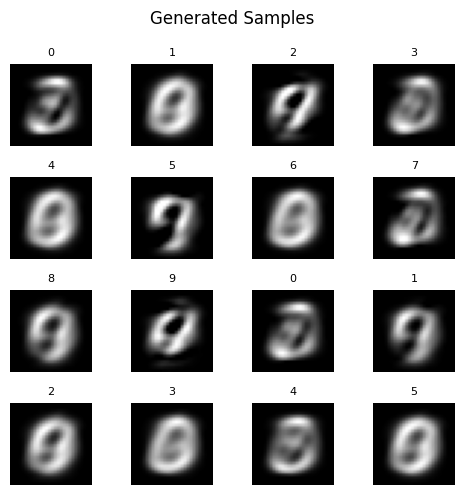

In [13]:
show_generated_samples(G, k, ranges, mins, pca, device)
